In [1]:
from flow_id import FlowID
from PIL import Image
from diffusers.utils import make_image_grid
from tqdm import tqdm
import torch
import gc

/home_pers/jripoll/anaconda3/envs/sd3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


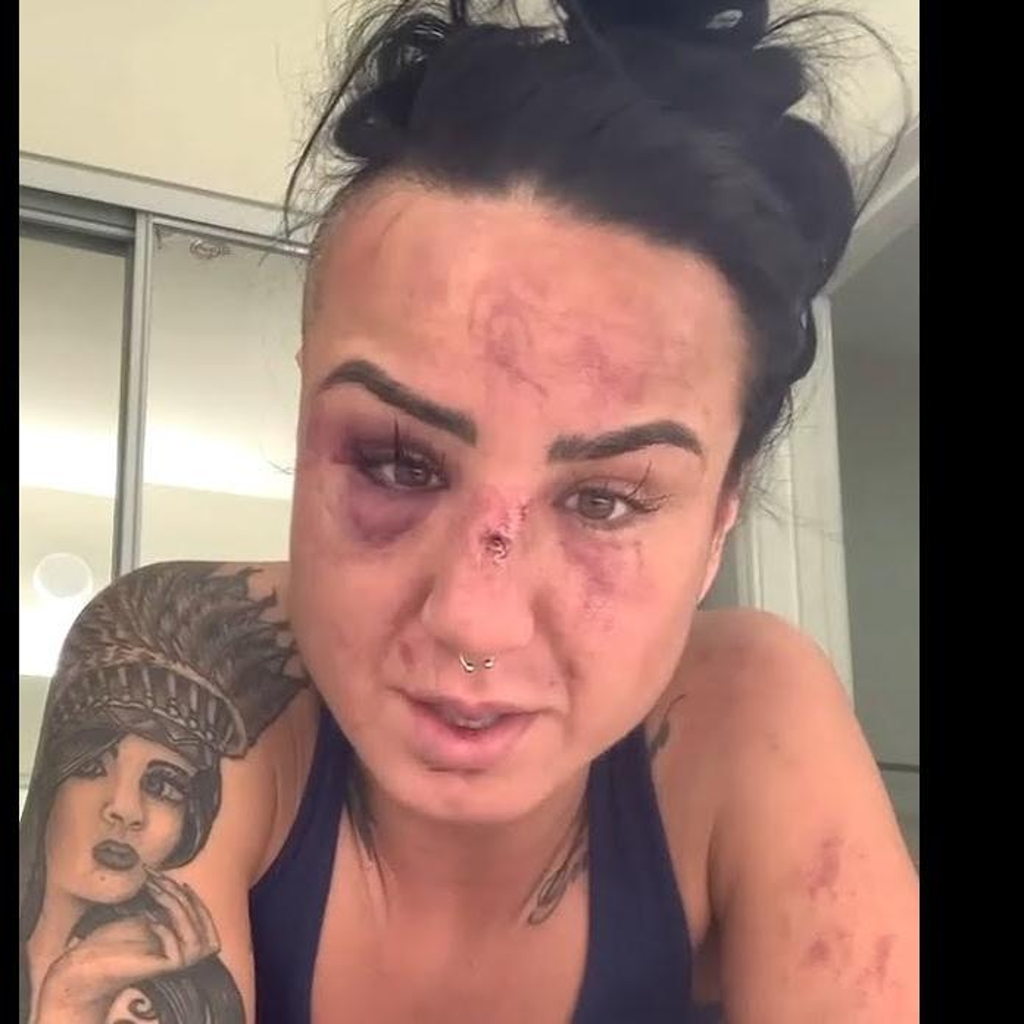

In [ ]:
image = Image.open("img.jpg").resize((1024,1024))
image

In [3]:
flowid = FlowID()

Loading pipeline components...:   0%|          | 0/8 [00:00<?, ?it/s]2026-01-19 17:58:56.882906626 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"
`torch_dtype` is deprecated! Use `dtype` instead!
Loading pipeline components...: 100%|██████████| 8/8 [00:06<00:00,  1.33it/s]


In [13]:
prompt = "a person's face, face injured, tattoo on the arm, tattoo on the breast"
flowid.ft_invert(
    img=image,
    prompt=prompt,
    num_train_steps=100
)

  0%|          | 0/1000 [00:00<?, ?it/s]/home_pers/jripoll/injuredfaces-bench/flow_id.py:191: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t=torch.tensor(sigmas*1000,device="cuda", dtype = torch.bfloat16)
100%|██████████| 1000/1000 [04:21<00:00,  3.82it/s]
50it [00:04, 12.31it/s]


here, preserving


0it [00:00, ?it/s]


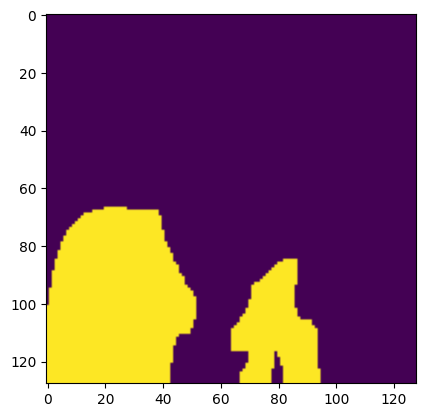

20it [00:03,  6.48it/s]


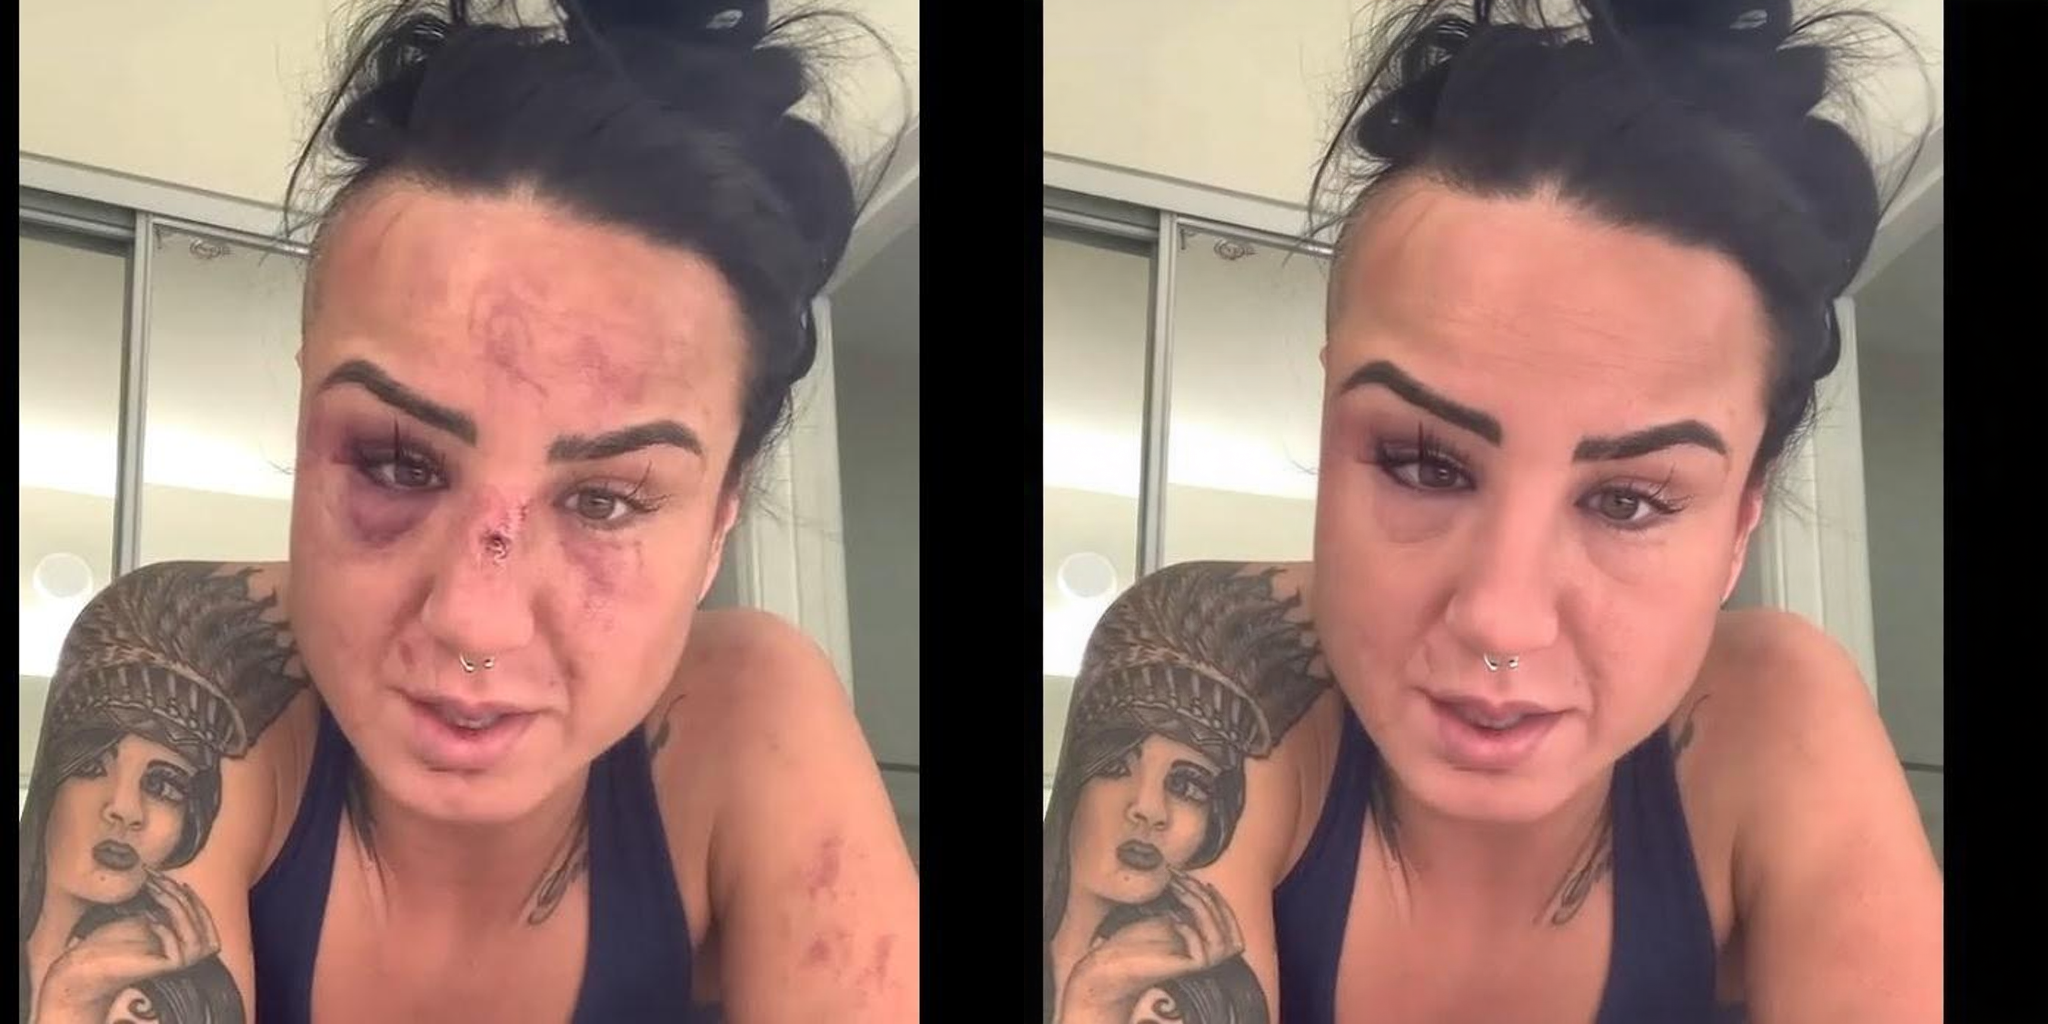

In [15]:
edited, mask = flowid.edit(
    prompt = "a person's face, tattoo on the arm, tattoo on the breast",
    neg_prompt = "face injured",
    num_skipped_steps = 30,
    concept = "tattoo on the arm, tattoo on the breast",
    pasting_cutoff = 0,
    kernel_size = 5,
    do_gaussian_blur = False,
    output_mask=True
)
make_image_grid([image,edited],rows=1,cols=2)